# 使用 subgraph

本指南讲解使用 subgraph 的机制。subgraph 是一个 [graph](https://docs.langchain.com/oss/langgraph/graph-api#graphs), 它在另一个 graph 中被用作 [node](https://docs.langchain.com/oss/langgraph/graph-api#nodes)。

subgraph 在以下场景很有用:
- 构建 [multi-agent 系统](https://docs.langchain.com/oss/langchain/multi-agent)
- 在多个 graph 中复用一组 node
- 分散开发: 当你希望不同团队独立处理 graph 的不同部分时, 可以把每个部分定义为一个 subgraph; 只要遵守 subgraph 接口 (输入与输出 schema), 父 graph 就能在完全不了解 subgraph 细节的情况下被构建出来

## 安装

```bash
pip install -U langgraph
```

In [1]:
# 环境准备: 从 .env 加载 API keys
from dotenv import load_dotenv

load_dotenv()  # 自动向上查找仓库根目录的 .env

# ---- 统一导入 ----
from typing_extensions import TypedDict

from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph
from langgraph.stream import UpdatesTransformer
from langgraph.types import Command, interrupt

# 本指南统一使用 DeepSeek 的 chat model
model = init_chat_model("deepseek:deepseek-chat", temperature=0)

In [2]:
from IPython.display import display, Image
from langgraph.graph.state import CompiledStateGraph

def show_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))

from rich import print as rprint


## 定义 subgraph 通信

添加 subgraph 时, 你需要定义父 graph 与 subgraph 之间如何通信:

| 模式 | 适用场景 | state schema |
|---------|------------|--------------|
| [在 node 内部调用 subgraph](#在-node-内部调用-subgraph) | 父 graph 与 subgraph 拥有**不同的 state schema** (没有共享的 key), 或者你需要在两者之间转换 state | 你编写一个包装函数, 把父 state 映射为 subgraph 输入, 再把 subgraph 输出映射回父 state |
| [把 subgraph 作为 node 添加](#把-subgraph-作为-node-添加) | 父 graph 与 subgraph **共享 state key** — subgraph 读写与父 graph 相同的通道 | 你把编译好的 subgraph 直接传给 `add_node` — 无需包装函数 |

### 在 node 内部调用 subgraph

当父 graph 与 subgraph 拥有**不同的 state schema** (没有共享的 key) 时, 在 node 函数内部调用该 subgraph。当你希望在 [multi-agent](https://docs.langchain.com/oss/langchain/multi-agent) 系统中为每个 agent 保留私有的 message 历史时, 这种做法很常见。

该 node 函数在调用 subgraph 之前把父 state 转换为 subgraph state, 并在返回之前把结果转换回父 state。

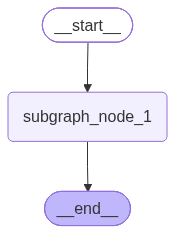

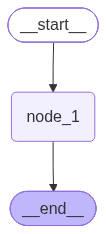

In [3]:
class SubgraphState(TypedDict):
    bar: str


# Subgraph
def subgraph_node_1(state: SubgraphState):
    return {"bar": "hi! " + state["bar"]}


subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph = subgraph_builder.compile()

show_graph(subgraph)


# Parent graph
class State(TypedDict):
    foo: str


def call_subgraph(state: State):
    # Transform the state to the subgraph state
    subgraph_output = subgraph.invoke({"bar": state["foo"]})
    # Transform response back to the parent state
    return {"foo": subgraph_output["bar"]}


builder = StateGraph(State)
builder.add_node("node_1", call_subgraph)
builder.add_edge(START, "node_1")
graph = builder.compile()

show_graph(graph)

### 把 subgraph 作为 node 添加

当父 graph 与 subgraph **共享 state key** 时, 你可以把编译好的 subgraph 直接传给 `add_node`。无需包装函数 — subgraph 会自动读写父 graph 的 state 通道。例如, 在 [multi-agent](https://docs.langchain.com/oss/langchain/multi-agent) 系统中, 各 agent 通常通过共享的 [messages](https://docs.langchain.com/oss/langgraph/graph-api#why-use-messages) key 进行通信。

![SQL agent graph](https://docs.langchain.com/oss/images/subgraph.png)

如果你的 subgraph 与父 graph 共享 state key, 可以按以下步骤把它添加到你的 graph 中:

1. 定义 subgraph workflow (下例中的 `subgraph_builder`) 并编译它
2. 在定义父 graph workflow 时, 把编译好的 subgraph 传给 `add_node` 方法

本节中的父 graph 与 subgraph 共享 `State`(`foo: str`), 该 schema 已在上文定义, 此处直接复用。

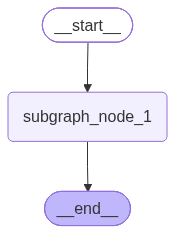

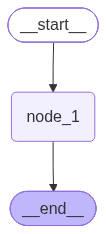

In [4]:
def subgraph_node_1(state: State):
    return {"foo": "hi! " + state["foo"]}


subgraph_builder = StateGraph(State)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph = subgraph_builder.compile()

show_graph(subgraph)


# Parent graph
builder = StateGraph(State)
builder.add_node("node_1", subgraph)
builder.add_edge(START, "node_1")
graph = builder.compile()

show_graph(graph)

## subgraph persistence

使用 subgraph 时, 你需要决定它的内部数据在多次调用之间如何处理。设想一个会委派给各个专门 subagent 的客户支持机器人: "账单专家" subagent 应该记住客户先前的提问, 还是在每次被调用时都从头开始?

`.compile()` 上的 `checkpointer` 参数控制 subgraph persistence:

| 模式 | `checkpointer=` | 行为 |
|------|-----------------|----------|
| [按调用](#按调用-默认) | `None` (默认) | 每次调用都从头开始, 并继承父 graph 的 checkpointer, 以在单次调用内支持 [interrupts](https://docs.langchain.com/oss/langgraph/interrupts) 与 [持久化执行](https://docs.langchain.com/oss/langgraph/persistence)。 |
| [按 thread](#按-thread) | `True` | state 在同一个 thread 上跨多次调用累积。每次调用都从上次离开的地方继续。 |
| [无状态](#无状态) | `False` | 完全不 checkpoint — 像普通函数调用一样运行。没有 interrupts, 也没有持久化执行。 |

对大多数应用来说, 按调用是合适的选择, 包括那些由 subagent 处理相互独立请求的 [multi-agent](https://docs.langchain.com/oss/langchain/multi-agent) 系统。当某个 subagent 需要多轮对话 memory 时 (例如一个在多次交流中逐步构建上下文的研究助理), 请使用按 thread。

> **注意**
>
> 父 graph 必须用 checkpointer 编译, subgraph persistence 的各项功能 (interrupts、state inspection、按 thread memory) 才能生效。见 [persistence](https://docs.langchain.com/oss/langgraph/persistence)。

> **提示**
>
> 以下示例使用 LangChain 的 `create_agent`, 这是构建 agent 的一种常见方式。`create_agent` 底层会产出一个 [LangGraph graph](https://docs.langchain.com/oss/langgraph/graph-api), 因此所有 subgraph persistence 概念都直接适用。如果你使用朴素的 LangGraph `StateGraph` 来构建, 相同的模式与配置选项同样适用 — 细节见 [Graph API](https://docs.langchain.com/oss/langgraph/graph-api)。

### 有状态

有状态的 subgraph 继承父 graph 的 checkpointer, 从而启用 [interrupts](https://docs.langchain.com/oss/langgraph/interrupts)、[persistence](https://docs.langchain.com/oss/langgraph/persistence) 与 state inspection。两种有状态模式的区别在于 state 保留的时长。

#### 按调用 (默认)

> **提示**
>
> 对大多数应用来说, 这是推荐模式, 包括那些把 subagent 作为 tool 调用的 [multi-agent](https://docs.langchain.com/oss/langchain/multi-agent) 系统。它支持 [interrupts](https://docs.langchain.com/oss/langgraph/interrupts)、[persistence](https://docs.langchain.com/oss/langgraph/persistence) 与并行调用, 同时让每次调用彼此隔离。

当对 subgraph 的每次调用都相互独立, 且 subagent 不需要记住先前调用的任何内容时, 请使用按调用 persistence。这是最常见的模式, 尤其适用于那些由 subagent 处理一次性请求的 [multi-agent](https://docs.langchain.com/oss/langchain/multi-agent) 系统, 例如 "查询该客户的订单" 或 "总结本文档"。

省略 `checkpointer`, 或把它设为 `None`。每次调用都从头开始, 但在单次调用内, subgraph 会继承父 graph 的 checkpointer, 并能使用 `interrupt()` 来暂停与恢复。

以下示例使用两个 subagent (水果专家、蔬菜专家), 它们被包装成供外层 agent 使用的 tool:

```python
@tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    return f"Info about {fruit_name}"

@tool
def veggie_info(veggie_name: str) -> str:
    """Look up veggie info."""
    return f"Info about {veggie_name}"

# Subagents - no checkpointer setting (inherits parent)
fruit_agent = create_agent(
    model=model,
    tools=[fruit_info],
    prompt="You are a fruit expert. Use the fruit_info tool. Respond in one sentence.",
)

veggie_agent = create_agent(
    model=model,
    tools=[veggie_info],
    prompt="You are a veggie expert. Use the veggie_info tool. Respond in one sentence.",
)

# Wrap subagents as tools for the outer agent
@tool
def ask_fruit_expert(question: str) -> str:
    """Ask the fruit expert. Use for ALL fruit questions."""
    response = fruit_agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
    )
    return response["messages"][-1].content

@tool
def ask_veggie_expert(question: str) -> str:
    """Ask the veggie expert. Use for ALL veggie questions."""
    response = veggie_agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
    )
    return response["messages"][-1].content

# Outer agent with checkpointer
agent = create_agent(
    model=model,
    tools=[ask_fruit_expert, ask_veggie_expert],
    prompt=(
        "You have two experts: ask_fruit_expert and ask_veggie_expert. "
        "ALWAYS delegate questions to the appropriate expert."
    ),
    checkpointer=MemorySaver(),
)
```

##### Interrupts

每次调用都可以使用 `interrupt()` 来暂停与恢复。把 `interrupt()` 加入某个 tool 函数, 即可在继续之前要求用户批准:

In [5]:
@tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    interrupt("continue?")
    return f"Info about {fruit_name}"

##### 多轮

每次调用都从一个全新的 subagent state 开始。subagent 不记得先前的调用:

```python
config = {"configurable": {"thread_id": "1"}}

# First call
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about apples"}]},
    config=config,
)
# Subagent message count: 4

# Second call - subagent starts fresh, no memory of apples
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Now tell me about bananas"}]},
    config=config,
)
# Subagent message count: 4 (still fresh!)
```

##### 多次 subgraph 调用

对同一个 subgraph 的多次调用可以无冲突地进行, 因为每次调用都会获得自己的 checkpoint namespace:

```python
config = {"configurable": {"thread_id": "1"}}

# LLM calls ask_fruit_expert for both apples and bananas
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about apples and bananas"}]},
    config=config,
)
# Subagent message count: 4 (apples - fresh)
# Subagent message count: 4 (bananas - fresh)
```

#### 按 thread

当某个 subagent 需要记住先前的交互时, 请使用按 thread persistence。例如, 一个在多次交流中逐步构建上下文的研究助理, 或一个追踪自己已编辑过哪些文件的编程助理。subagent 的对话历史与数据会在同一个 thread 上跨多次调用累积。每次调用都从上次离开的地方继续。

用 `checkpointer=True` 编译即可启用此行为。

> **警告**
>
> 按 thread 的 subgraph 不支持并行 tool 调用。当 LLM 可以把某个按 thread 的 subagent 作为 tool 使用时, 它可能会尝试并行地多次调用该 tool (例如同时向水果专家询问苹果和香蕉)。这会导致 checkpoint 冲突, 因为两次调用都写入同一个 namespace。
>
> 以下示例使用 LangChain 的 `ToolCallLimitMiddleware` 来避免这种情况。如果你使用纯 LangGraph `StateGraph` 来构建, 则需要自行避免并行 tool 调用 — 例如, 通过配置你的 model 禁用并行 tool 调用, 或者添加逻辑以确保同一个 subgraph 不会被并行地多次调用。

以下示例使用一个用 `checkpointer=True` 编译的水果专家 subagent。`fruit_info` 与 `ask_fruit_expert` 已在上文定义, 此处直接复用:

```python
# Subagent with checkpointer=True for persistent state
fruit_agent = create_agent(
    model=model,
    tools=[fruit_info],
    prompt="You are a fruit expert. Use the fruit_info tool. Respond in one sentence.",
    checkpointer=True,
)

# Outer agent with checkpointer
# Use ToolCallLimitMiddleware to prevent parallel calls to per-thread subagents,
# which would cause checkpoint conflicts.
agent = create_agent(
    model=model,
    tools=[ask_fruit_expert],
    prompt="You have a fruit expert. ALWAYS delegate fruit questions to ask_fruit_expert.",
    middleware=[
        ToolCallLimitMiddleware(tool_name="ask_fruit_expert", run_limit=1),
    ],
    checkpointer=MemorySaver(),
)
```

##### Interrupts

按 thread 的 subagent 与按调用一样支持 `interrupt()`, 把 `interrupt()` 加入某个 tool 函数即可要求用户批准 — 此处直接复用上文定义的 `fruit_info` (已加入 `interrupt()`)。

##### 多轮

state 会跨多次调用累积 — subagent 会记住过去的对话:

```python
config = {"configurable": {"thread_id": "1"}}

# First call
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about apples"}]},
    config=config,
)
# Subagent message count: 4

# Second call - subagent REMEMBERS apples conversation
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Now tell me about bananas"}]},
    config=config,
)
# Subagent message count: 8 (accumulated!)
```

##### 多次 subgraph 调用

当你有多个**不同的**按 thread subgraph 时 (例如一个水果专家和一个蔬菜专家), 每个都需要自己的存储空间, 以免它们的 checkpoint 相互覆盖。这被称为 **namespace 隔离**。

如果你 [在 node 内部调用 subgraph](#在-node-内部调用-subgraph), LangGraph 会按调用顺序 (第一次调用、第二次调用, 等等) 分配 namespace。这意味着重新排列调用顺序可能会打乱哪个 subgraph 加载哪份 state。为避免这种情况, 请把每个 subagent 包装进它自己的 `StateGraph`, 并使用唯一的 node 名称 — 这样每个 subgraph 都会得到一个稳定、唯一的 namespace:

```python
from langgraph.graph import MessagesState, StateGraph

def create_sub_agent(model, *, name, **kwargs):
    """Wrap an agent with a unique node name for namespace isolation."""
    agent = create_agent(model=model, name=name, **kwargs)
    return (
        StateGraph(MessagesState)
        .add_node(name, agent)  # unique name → stable namespace
        .add_edge("__start__", name)
        .compile()
    )


fruit_agent = create_sub_agent(
    model, name="fruit_agent",
    tools=[fruit_info], prompt="...", checkpointer=True,
)
veggie_agent = create_sub_agent(
    model, name="veggie_agent",
    tools=[veggie_info], prompt="...", checkpointer=True,
)

config = {"configurable": {"thread_id": "1"}}

# First call - LLM calls both fruit and veggie experts
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about cherries and broccoli"}]},
    config=config,
)
# Fruit subagent message count: 4
# Veggie subagent message count: 4

# Second call - both agents accumulate independently
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Now tell me about oranges and carrots"}]},
    config=config,
)
# Fruit subagent message count: 8 (remembers cherries!)
# Veggie subagent message count: 8 (remembers broccoli!)
```

[作为 node 添加](#把-subgraph-作为-node-添加) 的 subgraph 已经会自动获得基于名称的 namespace, 因此不需要这种包装。

### 无状态

当你希望像普通函数调用那样运行某个 subagent、且不承担任何 checkpoint 开销时, 请使用这种方式。subgraph 无法暂停 / 恢复, 也无法从 [持久化执行](https://docs.langchain.com/oss/langgraph/persistence) 中获益。用 `checkpointer=False` 编译。

> **警告**
>
> 没有 checkpoint 时, subgraph 就没有持久化执行。如果进程在运行中途崩溃, subgraph 无法恢复, 必须从头重新运行。

```python
subgraph_builder = StateGraph(...)
subgraph = subgraph_builder.compile(checkpointer=False)
```

### checkpointer 参考

用 `.compile()` 上的 `checkpointer` 参数控制 subgraph persistence:

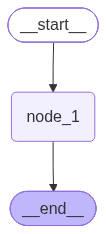

In [6]:
subgraph = builder.compile(checkpointer=False)  # or True / None

show_graph(subgraph)

| 功能 | 按调用 (默认) | 按 thread | 无状态 |
|---|---|---|---|
| `checkpointer=` | `None` | `True` | `False` |
| Interrupts (HITL) | ✅ | ✅ | ❌ |
| 多轮 memory | ❌ | ✅ | ❌ |
| 多次调用 (不同的 subgraph) | ✅ | ⚠️ (同一 node 内对多个按 thread subgraph 的调用可能导致 namespace 冲突, 有可用的 workaround) | ✅ |
| 多次调用 (同一个 subgraph) | ✅ | ❌ | ✅ |
| state inspection | ⚠️ (按调用模式下仅能查看当前调用(处于 interrupt 时)的 state; 每次调用都从头开始, 调用完成后没有累积的 state 可查) | ✅ | ❌ |

- **Interrupts (HITL)**: subgraph 可以使用 [interrupt()](https://docs.langchain.com/oss/langgraph/interrupts) 暂停执行并等待用户输入, 然后从上次离开的地方恢复。
- **多轮 memory**: subgraph 在同一个 [thread](https://docs.langchain.com/oss/langgraph/checkpointers#threads) 内跨多次调用保留其 state。每次调用都从上次离开的地方继续, 而不是从头开始。
- **多次调用 (不同的 subgraph)**: 可以在单个 node 内调用多个不同的 subgraph 实例, 而不会发生 checkpoint namespace 冲突。
- **多次调用 (同一个 subgraph)**: 可以在单个 node 内多次调用同一个 subgraph 实例。在有状态 persistence 下, 这些调用会写入同一个 checkpoint namespace 并发生冲突 — 请改用按调用 persistence。
- **state inspection**: 可以通过 `get_state(config, subgraphs=True)` 获取 subgraph 的 state, 用于调试与监控。

## 查看 subgraph state

当你启用 [persistence](https://docs.langchain.com/oss/langgraph/persistence) 后, 可以使用 subgraphs 选项来检查 subgraph state。在 [无状态](#无状态) checkpointing (`checkpointer=False`) 下, 不会保存任何 subgraph checkpoint, 因此无法获取 subgraph state。

> **注意**
>
> 查看 subgraph state 要求 LangGraph 能够**静态发现**该 subgraph — 也就是说, 它被 [作为 node 添加](#把-subgraph-作为-node-添加) 或 [在 node 内部调用](#在-node-内部调用-subgraph)。当 subgraph 在 [tool](https://docs.langchain.com/oss/langchain/tools) 函数内部或其他间接层中被调用时 (例如 [subagents](https://docs.langchain.com/oss/langchain/multi-agent/subagents) 模式), 查看功能不生效。无论嵌套多深, interrupts 仍会传播到顶层 graph。

### 按调用

仅返回**当前调用**的 subgraph state。每次调用都从头开始。

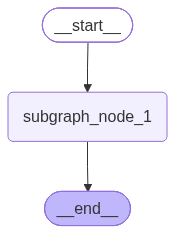

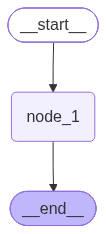

{'foo': 'bar'}

In [7]:
def subgraph_node_1(state: State):
    value = interrupt("Provide value:")
    return {"foo": state["foo"] + value}


subgraph_builder = StateGraph(State)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph = subgraph_builder.compile()  # inherits parent checkpointer

show_graph(subgraph)


# Parent graph
builder = StateGraph(State)
builder.add_node("node_1", subgraph)
builder.add_edge(START, "node_1")

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

show_graph(graph)

config = {"configurable": {"thread_id": "1"}}

graph.invoke({"foo": ""}, config)

# View subgraph state for the current invocation
subgraph_state = graph.get_state(config, subgraphs=True).tasks[0].state

# Resume the subgraph
rprint(graph.invoke(Command(resume="bar"), config))

### 按 thread

返回此 thread 上所有调用**累积**的 subgraph state。

```python
from langgraph.graph import START, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver

# Subgraph with its own persistent state
subgraph_builder = StateGraph(MessagesState)
# ... add nodes and edges
subgraph = subgraph_builder.compile(checkpointer=True)

# Parent graph
builder = StateGraph(MessagesState)
builder.add_node("agent", subgraph)
builder.add_edge(START, "agent")

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "1"}}

graph.invoke({"messages": [{"role": "user", "content": "hi"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "what did I say?"}]}, config)

# View accumulated subgraph state (includes messages from both invocations)
subgraph_state = graph.get_state(config, subgraphs=True).tasks[0].state
```

## stream subgraph 输出

要观察嵌套的 graph 执行, 我们推荐使用 [event streaming](https://docs.langchain.com/oss/langgraph/event-streaming): `stream.subgraphs` 投影会发现每个嵌套 run, 并在无需解析 namespace 字符串的情况下暴露其 `path`、`messages` 与 `values`。

下面使用上文 "把 subgraph 作为 node 添加" 的示例结构 (父 graph 的 `node_1` -> `node_2`, 其中 `node_2` 是一个 subgraph) 来演示:

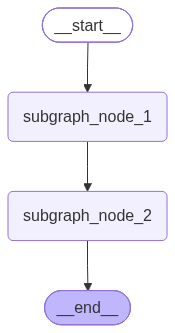

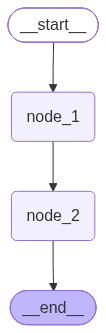

In [8]:
class SubgraphState(TypedDict):
    foo: str
    bar: str


def subgraph_node_1(state: SubgraphState):
    return {"bar": "bar"}


def subgraph_node_2(state: SubgraphState):
    # note that this node is using a state key ('bar') that is only available in the subgraph
    # and is sending update on the shared state key ('foo')
    return {"foo": state["foo"] + state["bar"]}


subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()

show_graph(subgraph)


# Parent graph
class ParentState(TypedDict):
    foo: str


def node_1(state: ParentState):
    return {"foo": "hi! " + state["foo"]}


builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", subgraph)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
graph = builder.compile()

show_graph(graph)

In [9]:
stream = graph.stream_events({"foo": "foo"}, version="v3")

for subgraph in stream.subgraphs:
    rprint(subgraph.graph_name, subgraph.path)

    for snapshot in subgraph.values:
        rprint(subgraph.path, snapshot)

C:\Users\Ashit\Documents\GitHub\LangChain-Docs\.venv\Lib\site-packages\langgraph\pregel\main.py:3708: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
C:\Users\Ashit\Documents\GitHub\LangChain-Docs\.venv\Lib\site-packages\langgraph\pregel\main.py:3558: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


node_2
('node_2:53a6c149-d79c-f29a-4b4d-f1168f2502d5',)

('node_2:53a6c149-d79c-f29a-4b4d-f1168f2502d5',)
{'foo': 'hi! foo', 'bar': 'bar'}

('node_2:53a6c149-d79c-f29a-4b4d-f1168f2502d5',)
{'foo': 'hi! foobar', 'bar': 'bar'}

如果你需要原始的 protocol 事件, 可以直接迭代 stream, 并依据 `event["method"]` 与 `event["params"]["namespace"]` 进行过滤:

In [10]:
stream = graph.stream_events({"foo": "foo"}, version="v3", transformers=[UpdatesTransformer])
for event in stream:
    if event["method"] == "updates":
        rprint(event["params"]["namespace"], event["params"]["data"])

[]
{'node_1': {'foo': 'hi! foo'}}

['node_2:e8010094-525e-f7ef-2ad9-a23e1d3ef11a']
{'subgraph_node_1': {'bar': 'bar'}}

['node_2:e8010094-525e-f7ef-2ad9-a23e1d3ef11a']
{'subgraph_node_2': {'foo': 'hi! foobar'}}

[]
{'node_2': {'foo': 'hi! foobar'}}